# Step 6 (RQ1) — Adapter Placement Study on CIFAR-FS  (Kaggle)

Compares **post_pool** (Step-4 baseline, reused) vs **serial** vs **parallel**
placement of the *same* 1×1 Bottleneck adapter inside a frozen ResNet-18, for
both heads (evidential + softmax) → 4 new `results/phase3_placement_*` JSONs.

**Kaggle setup (do this first):**
1. **Settings → Accelerator → GPU T4**, and **Settings → Internet → On**.
2. **Add Data** → attach your `bpeft-data` dataset (holding
   `cifar-100-python.tar.gz` + `test_32x32.mat`). TinyImageNet downloads at runtime.
3. Run top to bottom. Results land in `/kaggle/working/thesis/results`; hit
   **Save Version** to keep them.

Runtime: the 4 configs are close to Bottleneck's cost (no Full-FT here), so ~30–60 min on a T4.

## 0. GPU + environment check

In [22]:
import torch, sys
print('python:', sys.version.split()[0])
print('torch :', torch.__version__)
print('cuda  :', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
assert torch.cuda.is_available(), 'Enable GPU: Settings > Accelerator > GPU T4'

python: 3.12.13
torch : 2.10.0+cu128
cuda  : True | Tesla T4


## 1. Clone the repo + install deps

Set `BRANCH` to the branch that has the Step 6 placement code. Needs Internet ON.

In [23]:
import os, subprocess

REPO_URL = 'https://github.com/notAvailable73/thesis.git'
BRANCH   = 'main'                      # <-- branch with the Step 6 commit
REPO_DIR = '/kaggle/working/thesis'

if not os.path.isdir(os.path.join(REPO_DIR, '.git')):
    subprocess.run(['git', 'clone', '--branch', BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', f'origin/{BRANCH}'], check=True)

os.chdir(REPO_DIR)
print('cwd:', os.getcwd())
print(subprocess.run(['git', 'log', '--oneline', '-1'], capture_output=True, text=True).stdout.strip())
!pip -q install -r requirements.txt
assert os.path.exists('src/adapters/placement.py'), \
    'MISSING src/adapters/placement.py — push the Step 6 commit to this BRANCH.'
print('Step 6 placement code present — good.')

HEAD is now at 84ac1c7 Merge pull request #4 from notAvailable73/Step-6-1X1-CONV
cwd: /kaggle/working/thesis
84ac1c7 Merge pull request #4 from notAvailable73/Step-6-1X1-CONV


From https://github.com/notAvailable73/thesis
 * branch            main       -> FETCH_HEAD


Step 6 placement code present — good.


## 2. Stage data from the attached Kaggle Dataset

Kaggle-native equivalent of the Colab Drive-staging: copy the archives the
loaders short-circuit on, so nothing downstream hits the slow cs.toronto.edu
host. CIFAR-100 + SVHN come from the `bpeft-data` dataset; TinyImageNet (~240 MB)
downloads at runtime (Internet ON — Kaggle's link to Stanford is fast).

In [24]:
import glob, os
paths = sorted(glob.glob('/kaggle/input/**', recursive=True))
for p in paths[:60]:
    print(('DIR  ' if os.path.isdir(p) else 'file ') + p)
print(f"... {len(paths)} entries total")


DIR  /kaggle/input/
DIR  /kaggle/input/datasets
DIR  /kaggle/input/datasets/hamimsaadalraji
DIR  /kaggle/input/datasets/hamimsaadalraji/bpeft-data
DIR  /kaggle/input/datasets/hamimsaadalraji/bpeft-data/cifar-100-python
DIR  /kaggle/input/datasets/hamimsaadalraji/bpeft-data/cifar-100-python/cifar-100-python
file /kaggle/input/datasets/hamimsaadalraji/bpeft-data/cifar-100-python/cifar-100-python/file.txt~
file /kaggle/input/datasets/hamimsaadalraji/bpeft-data/cifar-100-python/cifar-100-python/meta
file /kaggle/input/datasets/hamimsaadalraji/bpeft-data/cifar-100-python/cifar-100-python/test
file /kaggle/input/datasets/hamimsaadalraji/bpeft-data/cifar-100-python/cifar-100-python/train
file /kaggle/input/datasets/hamimsaadalraji/bpeft-data/test_32x32.mat
... 11 entries total


In [25]:
import os, shutil, hashlib, glob

os.makedirs('data/svhn', exist_ok=True)
CIFAR_MD5 = 'eb9058c3a382ffc7106e4002c42a8d85'

def _find_file(name):
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else None

def _find_cifar_root():
    # The dir that DIRECTLY holds the CIFAR-100 python files (train/test/meta),
    # whatever the nesting. Kaggle often auto-extracts .tar.gz on upload (and can
    # double-nest it), so we locate the data by its marker files, not by name.
    for meta in glob.glob('/kaggle/input/**/meta', recursive=True):
        d = os.path.dirname(meta)
        if os.path.exists(os.path.join(d, 'train')) and os.path.exists(os.path.join(d, 'test')):
            return d
    return None

# ---- CIFAR-100: accept the tarball OR the extracted files (any nesting) ----
# ensure_archive / torchvision short-circuit on an extracted data/cifar-100-python/.
if os.path.isdir('data/cifar-100-python') or \
   (os.path.exists('data/cifar-100-python.tar.gz') and os.path.getsize('data/cifar-100-python.tar.gz') > 0):
    print('[cifar] already staged')
else:
    tar = _find_file('cifar-100-python.tar.gz')
    root = _find_cifar_root()
    if tar:
        shutil.copy(tar, 'data/cifar-100-python.tar.gz')
        assert hashlib.md5(open('data/cifar-100-python.tar.gz', 'rb').read()).hexdigest() == CIFAR_MD5
        print('[cifar] staged tarball (md5 OK)')
    elif root:
        shutil.copytree(root, 'data/cifar-100-python')
        print(f'[cifar] copied extracted files from {root}')
        print('        contents ->', sorted(os.listdir('data/cifar-100-python')))
    else:
        raise AssertionError('CIFAR-100 not found under /kaggle/input (no tarball, no '
                             'train/test/meta) — is bpeft-data attached? (sidebar: + Add Input)')

# ---- SVHN test_32x32.mat -> data/svhn/ ----
dst = 'data/svhn/test_32x32.mat'
if not (os.path.exists(dst) and os.path.getsize(dst) > 0):
    src = _find_file('test_32x32.mat')
    assert src, 'test_32x32.mat not found under /kaggle/input — add it to bpeft-data.'
    shutil.copy(src, dst)
    print(f'[svhn] staged {dst}  ({os.path.getsize(dst)/1e6:.0f} MB)')
else:
    print(f'[svhn] already present at {dst}')

# ---- TinyImageNet: stage from the dataset if present, else download at runtime ----
tin = _find_file('tiny-imagenet-200.zip')
if tin:
    shutil.copy(tin, 'data/tiny-imagenet-200.zip')
    print('[tin] staged tiny-imagenet-200.zip from the dataset')
else:
    print('[tin] not in dataset — will download at runtime (Internet ON)')

[cifar] already staged
[svhn] already present at data/svhn/test_32x32.mat
[tin] not in dataset — will download at runtime (Internet ON)


## 3. Build the frozen CIFAR-FS Bertinetto split

`data/` is gitignored, so materialize the canonical 64/16/20 split once.

In [26]:
!python scripts/build_cifar_fs_split.py
import json
sp = json.load(open('data/cifar_fs_split.json'))
print('split status:', sp.get('_status'))
print('sizes:', {k: len(v) for k, v in sp.items() if isinstance(v, list)})
assert sp.get('_status') != 'synthetic_fallback', 'split is the SYNTHETIC fallback — fix before running'

wrote /kaggle/working/thesis/data/cifar_fs_split.json  (64/16/20, disjoint, union=100, status=canonical_bertinetto_via_torchmeta)
split status: canonical_bertinetto_via_torchmeta
sizes: {'train': 64, 'val': 16, 'test': 20}


## 4. (optional) Tests

Confirm the new placement code passes before burning GPU.

In [27]:
!python -u -m pytest -q tests/test_placement.py
# full suite (slower):
# !python -u -m pytest -q

............                                                             [100%]
12 passed in 5.72s


## 5. Run the 4 placement configs (train + 600-episode eval)

serial/parallel × evidential/softmax. Already-finished configs are skipped, so
you can re-run this cell to resume. post_pool is reused from Step 4.5 (no run).

In [28]:
import subprocess, os

NUM_EPISODES = 600
RUNS = [
    ('exp_phase3_placement_serial_evidential',   'serial'),
    ('exp_phase3_placement_serial_softmax',      'serial'),
    ('exp_phase3_placement_parallel_evidential', 'parallel'),
    ('exp_phase3_placement_parallel_softmax',    'parallel'),
]

def head_desc(name):
    return 'prototype-evidential' if name.endswith('evidential') else 'prototype-softmax'

def result_path(placement, name):
    return f'results/phase3_placement_{placement}_bottleneck_{head_desc(name)}_metrics.json'

def run(cmd):
    print('>>>', ' '.join(cmd), flush=True)
    return subprocess.run(cmd).returncode

status = {}
for name, placement in RUNS:
    out = result_path(placement, name)
    if os.path.exists(out):
        print(f'== SKIP {name} (found {out}) =='); status[name] = 'skip (exists)'; continue
    print(f'\n{"="*72}\n== {name} ==\n{"="*72}', flush=True)
    cfg = f'configs/{name}.yaml'
    rc = run(['python', 'scripts/train.py', '--config', cfg, '--wandb-mode', 'disabled'])
    if rc != 0:
        status[name] = f'TRAIN failed (rc={rc})'; continue
    rc = run(['python', 'scripts/evaluate.py', '--config', cfg,
              '--num-episodes', str(NUM_EPISODES), '--wandb-mode', 'disabled',
              '--results-suffix', f'phase3_placement_{placement}', '--use-tinyimagenet'])
    status[name] = 'OK' if (rc == 0 and os.path.exists(out)) else f'EVAL failed (rc={rc})'

print('\n' + '=' * 40 + '\nRUN STATUS\n' + '=' * 40)
for name, _ in RUNS:
    print(f'  {name:44s} {status.get(name, "not run")}')


== exp_phase3_placement_serial_evidential ==
>>> python scripts/train.py --config configs/exp_phase3_placement_serial_evidential.yaml --wandb-mode disabled
[06:14:45] INFO bpeft.train: config: configs/exp_phase3_placement_serial_evidential.yaml  seed: 42  trainer.type: episodic
[06:14:45] INFO bpeft.train: wandb: disabled (no-op logger)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s] 


[06:14:48] INFO bpeft.train: trainable params: 31,746
[06:15:52] INFO bpeft.train: epoch   1/30  train_loss=0.3877  train_acc=0.883  val_loss=0.5214  val_acc=0.844  kl_w=0.010  mean_ev=1.8766  grad_norm=0.6818  global_step=100
[06:16:53] INFO bpeft.train: epoch   2/30  train_loss=0.3469  train_acc=0.880  val_loss=0.4994  val_acc=0.846  kl_w=0.020  mean_ev=1.9629  grad_norm=0.6919  global_step=200
[06:17:56] INFO bpeft.train: epoch   3/30  train_loss=0.3270  train_acc=0.897  val_loss=0.4658  val_acc=0.845  kl_w=0.030  mean_ev=2.1542  grad_norm=0.8177  global_step=300
[06:19:00] INFO bpeft.train: epoch   4/30  train_loss=0.3248  train_acc=0.894  val_loss=0.4700  val_acc=0.842  kl_w=0.040  mean_ev=2.1211  grad_norm=0.8380  global_step=400
[06:20:05] INFO bpeft.train: epoch   5/30  train_loss=0.3128  train_acc=0.899  val_loss=0.4371  val_acc=0.848  kl_w=0.050  mean_ev=2.2638  grad_norm=0.8395  global_step=500
[06:21:09] INFO bpeft.train: epoch   6/30  train_loss=0.3265  train_acc=0.893  va

## 6. Summary table

The 4 placement runs alongside the reused post_pool (Step 4.5) baseline.

In [29]:
import glob, json, os
import pandas as pd

rows = []
files = sorted(glob.glob('results/phase3_placement_*_metrics.json')) + \
        sorted(glob.glob('results/step45_bottleneck_*_metrics.json'))
for f in files:
    d = json.load(open(f)); base = os.path.basename(f)
    placement = ('post_pool' if base.startswith('step45')
                 else ('serial' if 'serial' in base else 'parallel'))
    rows.append({
        'placement': placement,
        'head'     : d.get('interpretation'),
        'n_params' : d.get('n_params'),
        'acc'      : round(d.get('accuracy_mean', float('nan')), 4),
        'f1'       : round(d.get('f1_macro_mean', float('nan')), 4),
        'ece'      : round(d.get('ece_pooled', float('nan')), 4),
        'ece_ts'   : round(d['ece_ts'], 4) if 'ece_ts' in d else None,
        'auroc_svhn': round(d.get('ood_auroc_mean', float('nan')), 4),
    })
df = pd.DataFrame(rows).sort_values(['placement', 'head']).reset_index(drop=True)
pd.set_option('display.width', 200); df

,placement,head,n_params,acc,f1,ece,ece_ts,auroc_svhn
0,parallel,evidential,31746,0.9146,0.9133,0.2824,NaN,0.9328
1,parallel,softmax,31744,0.9125,0.9111,0.0631,0.0170,0.8875
2,post_pool,evidential,16914,0.8835,0.8819,0.2846,NaN,0.9141
3,post_pool,softmax,16912,0.8747,0.8729,0.0817,0.0406,0.8378
4,serial,evidential,31746,0.9145,0.9127,0.2859,NaN,0.8887
5,serial,softmax,31744,0.9130,0.9115,0.0811,0.0140,0.8694


## 7. Comparison plot (RQ1)

saved /kaggle/working/thesis/results/step6_placement_comparison.png


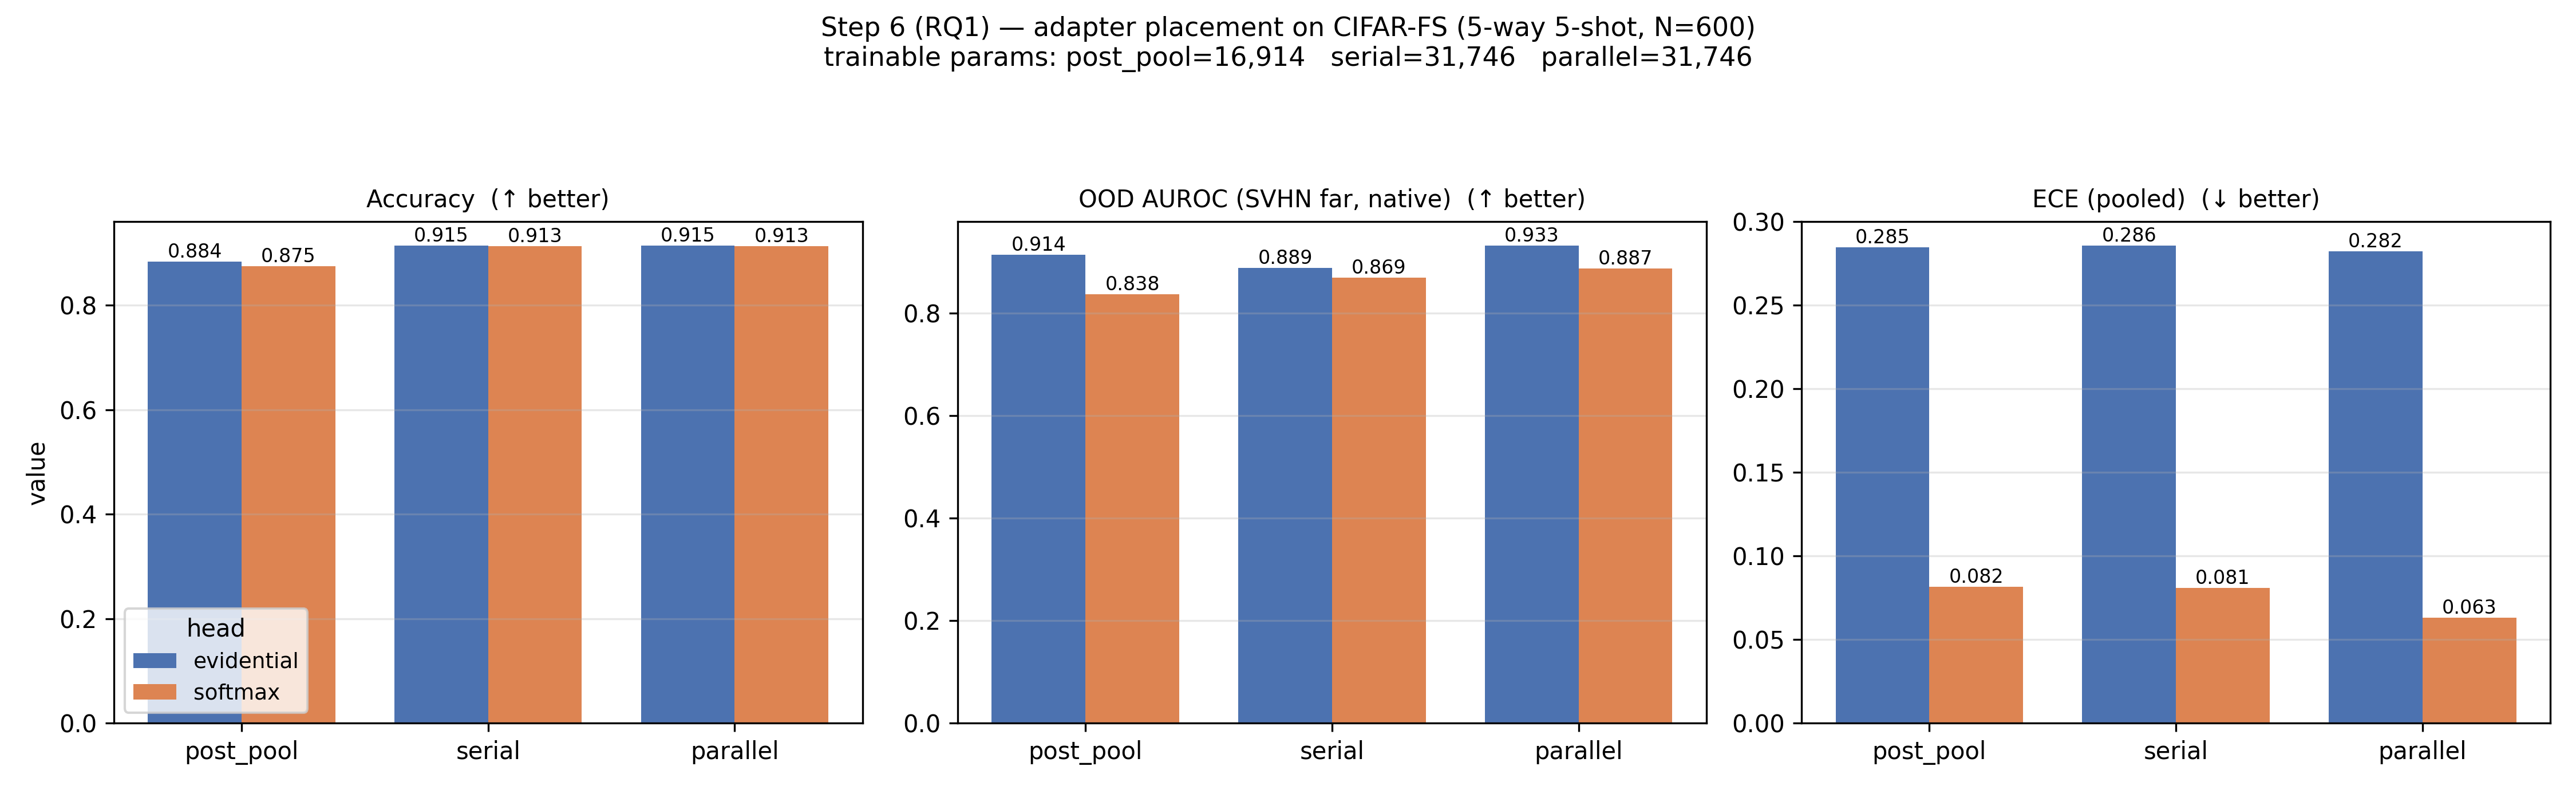

In [30]:
!python scripts/step6_placement_plot.py
from IPython.display import Image
Image('results/step6_placement_comparison.png')

## 8. Persist

Results are under `/kaggle/working/thesis/results` (kept as notebook output).
Click **Save Version** to snapshot. Download the 4 `phase3_placement_*` JSONs +
`step6_placement_comparison.png` to commit them back to the repo locally.